<a href="https://colab.research.google.com/github/DebanganRaj/data-science-project/blob/main/Iris%20flower%20detection%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CLUSTERING EXPERIMENT (UNSUPERVISED ML)

##STEP 1 — Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

##STEP 2 — Load Dataset

We will use the Iris dataset.

In [ ]:
data = load_iris()

df = pd.DataFrame(data.data, columns=data.feature_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


This dataset contains measurements of flowers such as:

sepal length

sepal width

petal length

petal width

##STEP 3 — Dataset Understanding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


##STEP 4 — Data Visualization

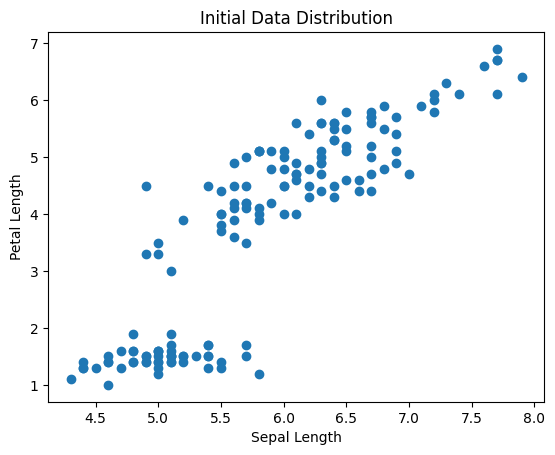

In [ ]:
plt.scatter(df['sepal length (cm)'], df['petal length (cm)'])
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Initial Data Distribution")
plt.show()

We can see that clusters may exist.

##STEP 5 — Feature Scaling

Clustering algorithms require scaled data.

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(df)

##STEP 6 — Finding Optimal Number of Clusters (Elbow Method)

In [ ]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

Plot elbow graph:

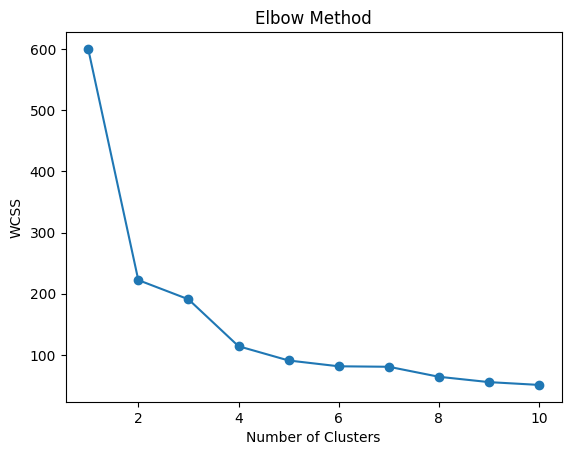

In [ ]:
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

Explanation

WCSS = Within Cluster Sum of Squares

The optimal cluster number is where the curve bends (elbow point).

For Iris dataset it is usually 3 clusters.

##STEP 7 — Apply K-Means Clustering

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X)

In [ ]:
df['Cluster'] = clusters

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,2
2,4.7,3.2,1.3,0.2,2
3,4.6,3.1,1.5,0.2,2
4,5.0,3.6,1.4,0.2,1


##STEP 8 — Visualize Clusters

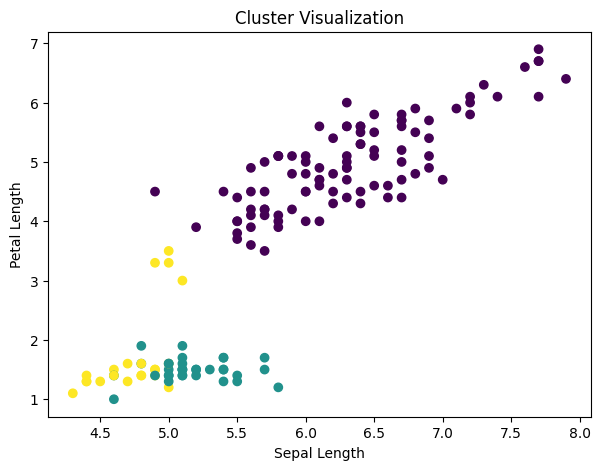

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(df['sepal length (cm)'], df['petal length (cm)'],
            c=df['Cluster'], cmap='viridis')

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Cluster Visualization")
plt.show()

##STEP 9 — View Cluster Centers

In [ ]:
kmeans.cluster_centers_

array([[ 0.57100359, -0.37176778,  0.69111943,  0.66315198],
       [-0.81623084,  1.31895771, -1.28683379, -1.2197118 ],
       [-1.32765367, -0.373138  , -1.13723572, -1.11486192]])

##STEP 10 — Cluster Interpretation

Cluster groups represent different flower types based on measurements.

Possible interpretation:

Cluster 0 → flowers with small petals
Cluster 1 → flowers with medium petals
Cluster 2 → flowers with large petals

Thus clustering discovers hidden patterns without labels.